<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- Feature Importance, Dimensionality Reduction, KNN --

## Import libraries

In [51]:
from tensorflow.keras.datasets import mnist
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import cv2

## Q1 - Load dataset

In [14]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Q2 - A plot for each number

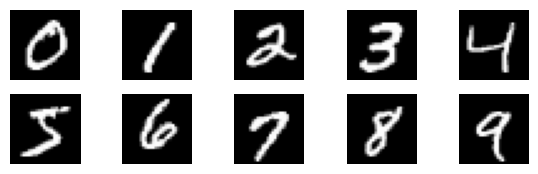

In [15]:
samples = []
for n in range(10):
  idx = np.argmax(y_train == n)#[0][0]
  samples.append(x_train[idx])
  # print(idx, n, y_train[idx])
# samples
plt.figure(1, figsize=(7,2))
for i in range(2):
  for j in range(5):
    pos = i*5 + j
    plt.subplot(2,5,pos+1)
    plt.imshow(samples[pos], cmap='grey')
    plt.axis('off')

## Q4 - What is the size of each image? Are all pixels equally significant?

The size of each image is 28x28 pixels. Each one of these pixels has a value in the range [0,255], representing its lightness value (0 being black, 255 white). No pixel value is inherently more significant than any other, as both black and white pixels convey the contrast pattern that eventually is what indicates which digit the image represents.

## Q4 - Convert the (x_train, x_test) matrices into vectors

In [16]:
size_train, size_test = len(x_train), len(x_test)
x_train_flat, x_test_flat = x_train.reshape(size_train, -1), x_test.reshape(size_test, -1)

## Q5 - Try out different values of k for KNN classification

In [17]:
knn = KNeighborsClassifier(n)
knn.fit(x_train_flat, y_train)
preds = knn.predict(x_test_flat)
accu_train_ = accuracy_score(y_test, preds)
accu_train_

0.9659

In [19]:
Ns = [5, 15, 51, int(np.sqrt(len(x_train)))]
accu_train = []
accu_test = []
for n in Ns:
  knn = KNeighborsClassifier(n)
  knn.fit(x_train_flat, y_train)
  train_preds = knn.predict(x_train_flat)
  test_preds = knn.predict(x_test_flat)
  accu_train.append(accuracy_score(y_train, train_preds))
  accu_test.append(accuracy_score(y_test, test_preds))

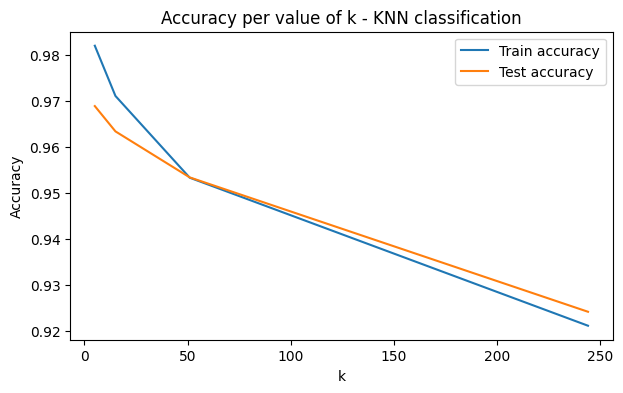

In [28]:
plt.figure(2,figsize=(7,4),)
plt.plot(Ns, accu_train, label='Train accuracy')
plt.plot(Ns, accu_test, label='Test accuracy');
plt.title('Accuracy per value of k - KNN classification')
plt.ylabel('Accuracy')
plt.xlabel('k')
plt.legend();

## Q6 - Assessing a normalized dataset

In [30]:
x_train_flat_norm, x_test_flat_norm = x_train_flat/255, x_test_flat/255
Ns = [5, 15, 51, int(np.sqrt(len(x_train)))]
accu_train_norm = []
accu_test_norm = []
for n in Ns:
  knn = KNeighborsClassifier(n)
  knn.fit(x_train_flat_norm, y_train)
  train_preds = knn.predict(x_train_flat_norm)
  test_preds = knn.predict(x_test_flat_norm)
  accu_train_norm.append(accuracy_score(y_train, train_preds))
  accu_test_norm.append(accuracy_score(y_test, test_preds))

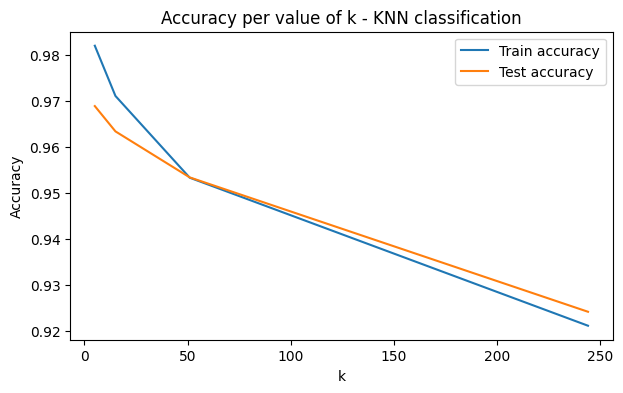

In [31]:
plt.figure(2,figsize=(7,4),)
plt.plot(Ns, accu_train_norm, label='Train accuracy')
plt.plot(Ns, accu_test_norm, label='Test accuracy');
plt.title('Accuracy per value of k - KNN classification')
plt.ylabel('Accuracy')
plt.xlabel('k')
plt.legend();

Comparing the results of the initial dataset and the normalized one, no noticeable change appears to be present between the two runs. While the distances of each neighbor for each run might have been reduced, the reduction was equal among the distances, so it had no effect on the end result. The best results appear to be achieved when n=5.

## Q7 - Testing the classifier on a hand-drawn digit

File ‘three_MNIST.png?raw=true’ already there; not retrieving.

[3]


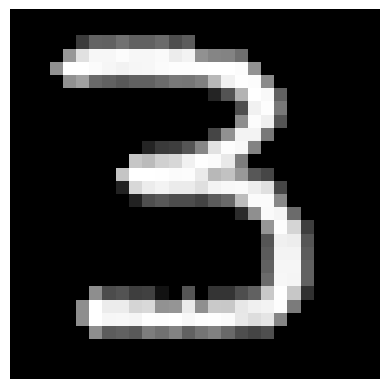

In [65]:
!wget -nc https://github.com/lazarosgogos/ML-exercises/blob/main/three_MNIST.png?raw=true


path = "/content/three_MNIST.png?raw=true"
target = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img_ = np.array(target)
img = img_.reshape(1, 28*28)
knn = KNeighborsClassifier(5)
knn.fit(x_train_flat_norm, y_train)
pred = knn.predict(img)
plt.figure(4)
plt.imshow(img_, cmap='gray')
plt.axis('off')
print(pred)

As shown in the result, the image corresponds to the predicted value of the digit, signifying the predictor works as intended.